## Load the data

Change the filename to the directory of the .dat file

In [1]:
import numpy as np
import mne
import sys
import os.path
import os
import pandas as pd
import matplotlib.pyplot as plt
from mne.datasets.fieldtrip_cmc import data_path
from mne_connectivity import spectral_connectivity_epochs

number_of_channels = 16
sample_rate = 250.4
sample_datatype = 'int16'
display_decimation = 1

filename="/Users/sekemiadenuga/Documents/Dissertation/Data/TAINI_1033_S7063_Baseline1-2020_01_27-0000.dat"

def load_dat(filename):
    '''Load a .dat file by interpreting it as int16 and then de-interlacing the 16 channels'''
   
    print("Loading_" + filename)

    # Load the raw (1-D) data
    dat_raw = np.fromfile(filename, dtype=sample_datatype)

    # Reshape the (2-D) per channel data
    step = number_of_channels * display_decimation
    dat_chans = [dat_raw[c::step] for c in range(number_of_channels)]

    # Build the time array
    t = np.arange(len(dat_chans[0]), dtype=float) / display_decimation

    data=np.array(dat_chans)
    print(len(data))
    del(dat_chans)
   
    n_channels=16

    channel_names=['1', '2', '3', '4', '5',
                           '6', '7', '8', '9', '10',
                           '11', '12', '13', '14', '15', '16']
##    channel_names=['PVN', 'PVN', 'EMG', 'MC_conra', 'MS',
#                           'MC_ipsi', 'MC_ipsi', 'MS', 'MEC', 'MEC',
#                           'MHPC_contra', 'blank', 'Mhpc_contra', 'MC_contra', 'Mhps_ipsi', 'Mhpc_ipsi']
    channel_types=['eeg','emg','eeg','eeg','eeg','eeg','eeg','eeg','eeg','eeg','eeg','eeg','eeg','eeg','eeg','eeg']
         
       
    'This creates the info that goes with the channels, which is names, sampling rate, and channel types.'
    info = mne.create_info(channel_names, sample_rate, channel_types)
   
   
    'This makes the object that contains all the data and info about the channels.'
    'Computations like plotting, averaging, power spectrums can be performed on this object'
   
    custom_raw = mne.io.RawArray( data, info)
     
   
    return custom_raw

custom_raw = load_dat(filename)  


Loading_/Users/sekemiadenuga/Documents/Dissertation/Data/TAINI_1033_S7063_Baseline1-2020_01_27-0000.dat
16
Creating RawArray with float64 data, n_channels=16, n_times=62187522
    Range : 0 ... 62187521 =      0.000 ... 248352.720 secs
Ready.


## Load seizure file paths and select the required time window

Check using manual calculation that the recording start time and crop window times are correct.

In [2]:
# File paths
sample_file = "/Users/sekemiadenuga/Documents/Dissertation/Data/Sample_start_end_SYNGAP.xlsx"
seizure_file = "/Users/sekemiadenuga/Documents/Dissertation/Data/S7063_BL1_Seizures_pre_120s.csv"

# Sampling rate
sampling_rate = 250.4  # Hz

# Read first row from the sample file
sample_df = pd.read_excel(sample_file)
first_row = sample_df.iloc[0]
start_sample = first_row['Start']

# Convert start sample to seconds
start_seconds = start_sample / sampling_rate
print(f"Start of recording in seconds: {start_seconds:.2f}")

# Read the CSV with tab separator
seizure_df = pd.read_csv(seizure_file, sep='\t')
first_seizure = seizure_df.iloc[0] # first line only

# Calculate crop window
crop_start = start_seconds + first_seizure['sec_start'] - 10 
crop_end = start_seconds + first_seizure['sec_start'] + 15
print(f"Crop window: {crop_start:.2f} s to {crop_end:.2f} s")

Start of recording in seconds: 61200.00
Crop window: 62814.30 s to 62839.30 s


## Crop data to the 25 second time window

In [3]:
raw_window = custom_raw.copy().crop(tmin=crop_start, tmax=crop_end)
raw_window.filter(l_freq=1.0, h_freq=40.0) 
data, times = raw_window.get_data(return_times=True)
ch_names = raw_window.ch_names

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 827 samples (3.303 s)



## Data Extraction

In [4]:
# Select Channel 1
channel = '1'
idx = ch_names.index(channel)
signal = data[idx]

# Preprocess
signal = signal - signal.mean()
times = times - times[0] # Normalise time so time starts at 0

## Create plot for Figure 1

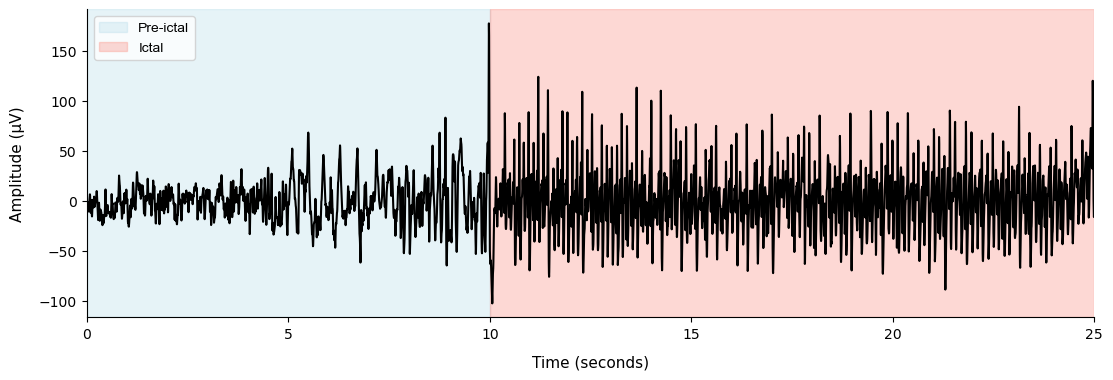

In [5]:
# Plot figure
plt.figure(figsize=(13, 4))
plt.plot(times, signal, color='black', linewidth=1.5)

# Labels
plt.xlabel("Time (seconds)", fontsize=11, labelpad = 10)
plt.ylabel("Amplitude (µV)", fontsize=11, labelpad = 10)
#plt.title(
    #f"Absence Seizure EEG Trace",
    #fontsize=12,
    #fontweight='bold'
#)
plt.rcParams['font.family'] = 'Arial'

# Stying
ax = plt.gca()
ax.margins(x=0)  # ← only change
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Background shading
plt.axvspan(0, 10, color='lightblue', alpha=0.3, label='Pre-ictal')
plt.axvspan(10, 25, color='salmon', alpha=0.3, label='Ictal')

# Legend
plt.legend(loc="upper left")
plt.show()